In [52]:
import numpy as np
import pandas as pd 

# ingest the data

In [53]:
df = pd.read_csv("online_retail.csv")

In [54]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [55]:
df.shape

(541909, 8)

# explore the dataset

In [56]:

pd.set_option('display.max_columns', None) 
def data_overview(df, head=5):
    print("DATA TYPES".center(125,'-'))
    print(df.dtypes.value_counts())
    
    print(" MISSING VALUES ".center(125,'-'))
    print(df.isnull().sum()[df.isnull().sum()>0].sort_values(ascending = False))
    
    print(" DUPLICATED VALUES ".center(125,'-'))
    print(df.duplicated().sum())
    
    print(" STATISTICS OF DATA ".center(125,'-'))
    print(df.describe(include="all"))
    
    print("DATA INFO".center(125,'-'))
    print(df.info())
    
    
data_overview(df)

----------------------------------------------------------DATA TYPES---------------------------------------------------------
object     5
float64    2
int64      1
Name: count, dtype: int64
------------------------------------------------------- MISSING VALUES ------------------------------------------------------
CustomerID     135080
Description      1454
dtype: int64
----------------------------------------------------- DUPLICATED VALUES -----------------------------------------------------
5268
----------------------------------------------------- STATISTICS OF DATA ----------------------------------------------------
       InvoiceNo StockCode                         Description       Quantity  \
count     541909    541909                              540455  541909.000000   
unique     25900      4070                                4223            NaN   
top       573585    85123A  WHITE HANGING HEART T-LIGHT HOLDER            NaN   
freq        1114      2313                   

# remove rows with missing customerid

In [57]:
df.dropna(subset=["CustomerID"],axis = 0 , inplace = True)
# axis = 0 => drop rows
# inplace = change the original df

# remove invalid prices

In [ ]:

df = df[df["UnitPrice"] > 0]


# fix missing values

In [59]:

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406789 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406789 non-null  object 
 1   StockCode    406789 non-null  object 
 2   Description  406789 non-null  object 
 3   Quantity     406789 non-null  int64  
 4   InvoiceDate  406789 non-null  object 
 5   UnitPrice    406789 non-null  float64
 6   CustomerID   406789 non-null  float64
 7   Country      406789 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [60]:
print("Missing values in each column after cleaning customerID :\n",df.isnull().sum())

Missing values in each column after cleaning customerID :
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [61]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# remove duplicates

In [66]:
print('before cleaning' , df.duplicated().sum())
df = df.drop_duplicates(keep='first')
print('after cleaning' , df.duplicated().sum())

before cleaning 5225
after cleaning 0


In [65]:
df.shape

(406789, 8)

In [67]:
df.shape

(401564, 8)

# check for negative values

In [75]:
print('negative quantity count', (df['Quantity']< 0).sum())

negative quantity count 8872


In [76]:
print('negative unit price count', (df.Quantity <0).sum())
df = df[df.Quantity > 0]
print('negative quantity count', (df['Quantity']< 0).sum())

negative unit price count 8872
negative quantity count 0


## check for outliers (negative value, very large value from average datapoints)


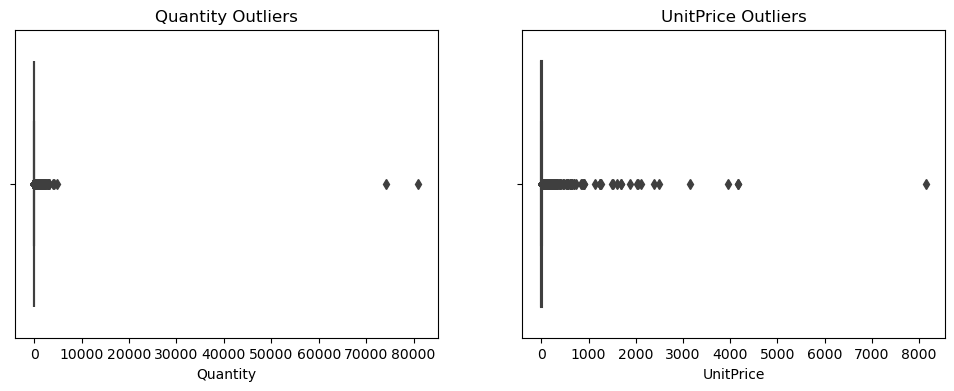

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df["Quantity"], ax=ax[0])
ax[0].set_title("Quantity Outliers")

sns.boxplot(x=df["UnitPrice"], ax=ax[1])
ax[1].set_title("UnitPrice Outliers")

plt.show()


In [93]:
#defining funcation to remove outliers w.r.t its thresholds
def outlier_thresholds(df, col):
    quartile1 = df[col].quantile(0.01)
    quartile3 = df[col].quantile(0.99)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return up_limit, low_limit

def replace_with_threshold(df, col):
    up_limit, low_limit = outlier_thresholds(df, col)
    # df.loc[(df[col] < low_limit), col] = low_limit
    df.loc[(df[col] > up_limit), col] = up_limit

In [94]:

# Applying the functions for remove the outlier.
replace_with_threshold(df, "Quantity")
replace_with_threshold(df, "UnitPrice")

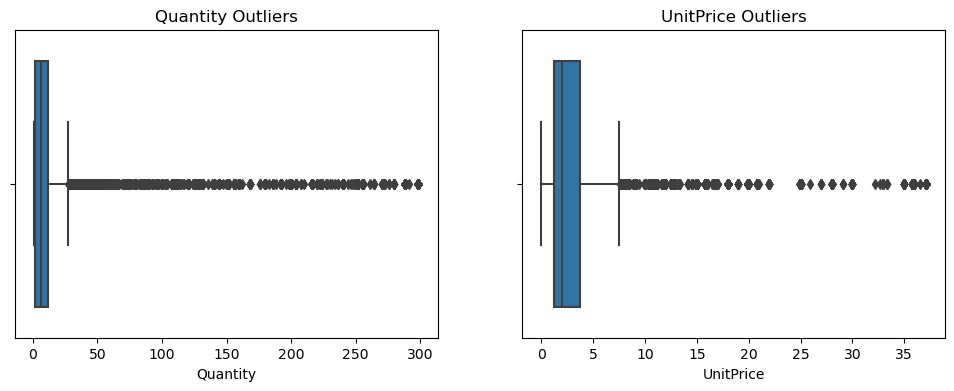

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df["Quantity"], ax=ax[0])
ax[0].set_title("Quantity Outliers")

sns.boxplot(x=df["UnitPrice"], ax=ax[1])
ax[1].set_title("UnitPrice Outliers")

plt.show()